In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import xarray as xr
from context_flux_no.simulations.pde import CubicFlux1D
from context_flux_no.simulations.utils import generate_dataset
from context_flux_no.waveforms.grf import (
    GaussianRandomField1D,
    PeriodicCov,
)
from context_flux_no.waveforms.step import PeriodicRandomStepFunction1D

2026-04-15 11:23:22,256 INFO CLAW: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


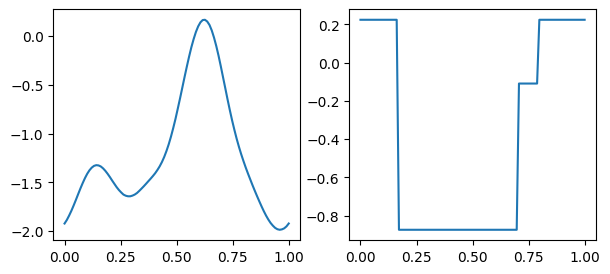

In [ ]:
x = jnp.linspace(0, 1, 100)
grf = GaussianRandomField1D(PeriodicCov(corr_length=1.0))
u0 = grf.sample(x, jax.random.key(10))

step = PeriodicRandomStepFunction1D()
u0_step = step.sample(x, jax.random.key(2))
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].plot(x, u0)
axes[1].plot(x, u0_step)

In [ ]:
dataset = generate_dataset(
    n_coeffs=100,
    n_ics_per_coeff=100,
    pde_factory=CubicFlux1D,
    initial_condition_fn=GaussianRandomField1D(PeriodicCov(1.0)).sample,
    coeff_range_dict={"a": (-1.0, 1.0), "b": (-1.0, 1.0), "c": (-1.0, 1.0)},
    x_span=(0, 1),
    Nx=100,
    t_span=(0, 0.5),
    Nt=1000,
    seed=0,
)


 53%|█████▎    | 53/100 [54:25<47:32, 60.70s/it]  

In [ ]:
dataset

<xarray.Dataset> Size: 801MB
Dimensions:  (pde: 100, ic: 10, t: 1001, dim: 1, x: 100, param: 3)
Coordinates:
  * t        (t) float64 8kB 0.0 0.0005 0.001 0.0015 ... 0.4985 0.499 0.4995 0.5
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * dim      (dim) <U1 4B 'u'
  * param    (param) <U1 12B 'a' 'b' 'c'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float64 801MB -0.1115 -0.1172 ... 0.7864
    coeffs   (pde, param) float64 2kB -0.4814 -0.2967 0.5484 ... -0.1377 0.806

In [ ]:
savedir = Path("../../data/")
savedir.mkdir(parents=True, exist_ok=True)
dataset.to_netcdf(savedir / "cubic_no_source_large_train.hdf5")

In [5]:
dataset_test = generate_dataset(
    n_coeffs=100,
    n_ics_per_coeff=10,
    pde_factory=CubicFlux1D,
    initial_condition_fn=GaussianRandomField1D(PeriodicCov(1.0)).sample,
    coeff_range_dict={"a": (-1.0, 1.0), "b": (-1.0, 1.0), "c": (-1.0, 1.0)},
    x_span=(0, 1),
    Nx=100,
    t_span=(0, 0.5),
    Nt=1000,
    seed=1,
)

savedir = Path("../../data/")
savedir.mkdir(parents=True, exist_ok=True)
dataset_test.to_netcdf(savedir / "cubic_no_source_test.hdf5")

100%|██████████| 100/100 [09:11<00:00,  5.51s/it]


## Concatenate datasets into single file

In [3]:
datadir = Path("../../data")
basename = "cubic_no_source_large_train"


In [4]:
ds = xr.open_mfdataset(
    sorted(list(datadir.glob(f"{basename}_seed=*.hdf5"))),
    combine="nested",
    concat_dim="pde",
    engine="h5netcdf",
)

In [5]:
ds = ds.astype("float32", casting="same_kind")

In [6]:
ds

<xarray.Dataset> Size: 40GB
Dimensions:  (pde: 1000, ic: 100, t: 1001, dim: 1, x: 100, param: 3)
Coordinates:
  * t        (t) float64 8kB 0.0 0.0005 0.001 0.0015 ... 0.4985 0.499 0.4995 0.5
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * dim      (dim) <U1 4B 'u'
  * param    (param) <U1 12B 'a' 'b' 'c'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float32 40GB dask.array<chunksize=(100, 100, 1001, 1, 100), meta=np.ndarray>
    coeffs   (pde, param) float32 12kB dask.array<chunksize=(100, 3), meta=np.ndarray>

In [7]:
ds.to_netcdf(datadir / f"{basename}.hdf5", engine="h5netcdf")